# Zuber — análise do mercado de táxis em Chicago

Análise exploratória do mercado de táxis em Chicago, com foco na concentração de corridas por empresa, principais bairros de destino e teste estatístico sobre a duração de viagens em diferentes condições climáticas.

**Ferramentas:** Python, pandas e scipy.


## Exploração do mercado de táxis

Nesta etapa são avaliados os principais operadores e destinos, além da qualidade e estrutura dos dados utilizados na análise.


### Carregamento e validação dos dados


In [1]:
import pandas as pd
from scipy import stats


#importando planilhas

trips_amount = pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/learning-materials/data-analyst-eng/moved_project_sql_result_01.csv')
trips_by_location = pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/learning-materials/data-analyst-eng/moved_project_sql_result_04.csv')


In [2]:
#visualizando dados
display(trips_amount)
display(trips_by_location)

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299
...,...,...
59,4053 - 40193 Adwar H. Nikola,7
60,2733 - 74600 Benny Jona,7
61,5874 - 73628 Sergey Cab Corp.,5
62,"2241 - 44667 - Felman Corp, Manuel Alonso",3


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
...,...,...
89,Mount Greenwood,3.137931
90,Hegewisch,3.117647
91,Burnside,2.333333
92,East Side,1.961538


In [3]:
# estudo dos dados
trips_amount.info()
trips_by_location.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


In [4]:
#estudo dos dados
display(trips_amount.describe())
trips_by_location.describe()

,trips_amount
count,64.000000
mean,2145.484375
std,3812.310186
min,2.000000
25%,20.750000
50%,178.500000
75%,2106.500000
max,19558.000000


,average_trips
count,94.000000
mean,599.953728
std,1714.591098
min,1.800000
25%,14.266667
50%,52.016667
75%,298.858333
max,10727.466667


In [5]:
display(trips_amount.duplicated().sum())
trips_by_location.duplicated().sum()

0

0

#### Conclusão preliminar

* Tipos de dados coerentes com campos
* Não há dados nulos nem duplicatas
* É possível que os dado float em average_trips possam ser limitados para uma ou duas casas decimais no futuro

### Principais bairros de destino


In [6]:
top10_destiny_neighb = trips_by_location.sort_values(by='average_trips', ascending=False).head(10)
display(top10_destiny_neighb)

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


Obs.: estou assumindo, até o momento, que os dados da primeira planilha dizem respeito a apenas dois dias de novembro, e que os dados da segunda dizem respeito a todo o mês, pois é a forma com que foram descritos.

### Visualizações


#### Corridas por empresa


,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299
...,...,...
59,4053 - 40193 Adwar H. Nikola,7
60,2733 - 74600 Benny Jona,7
61,5874 - 73628 Sergey Cab Corp.,5
62,"2241 - 44667 - Felman Corp, Manuel Alonso",3


<AxesSubplot:>

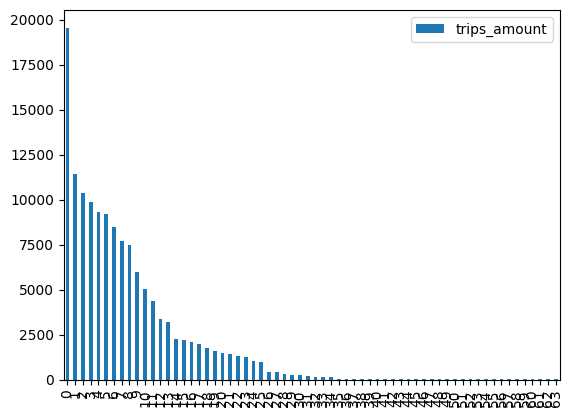

In [7]:
##visualizando dados

display(trips_amount)
trips_amount.plot(kind = 'bar')

#### Ajuste de visualização

O gráfico com as 64 empresas ficou pouco legível. Para melhorar a comparação, as dez maiores empresas são mantidas individualmente e as demais são agregadas em uma categoria única.


<AxesSubplot:title={'center':'Nº de corridas x empresa (15-16 nov.2017)'}, xlabel='Empresa', ylabel='Nº de corridas'>

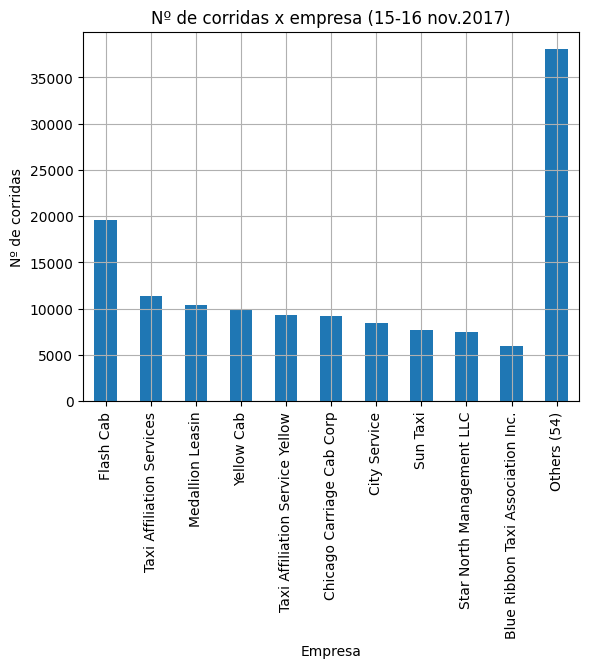

In [8]:
#melhorando gráfico para visualização

trips_amount_top10 = trips_amount.loc[0:9]
trips_amount_others = trips_amount.loc[10:]
trips_amount_others_sum = trips_amount_others['trips_amount'].sum()

#criando df pro gráfico
trips_amount_others_sum_df = pd.DataFrame({
    'company_name' : ['Others (54)'],
    'trips_amount' : [trips_amount_others_sum]
})

trips_amount_top10_and_others = pd.concat([
    trips_amount_top10, trips_amount_others_sum_df]).reset_index(drop=True)

#gerando gráfico
trips_amount_top10_and_others.plot(kind='bar', title = 'Nº de corridas x empresa (15-16 nov.2017)', x = 'company_name', y='trips_amount',  xlabel = 'Empresa', ylabel = 'Nº de corridas', grid=True, legend=False)

#### Top 10 bairros por média de corridas


In [9]:
display(top10_destiny_neighb)

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


<AxesSubplot:title={'center':'Média de viagens x dia x bairro (nov/2017)'}, xlabel='Bairros de destino', ylabel='Viagens x dia'>

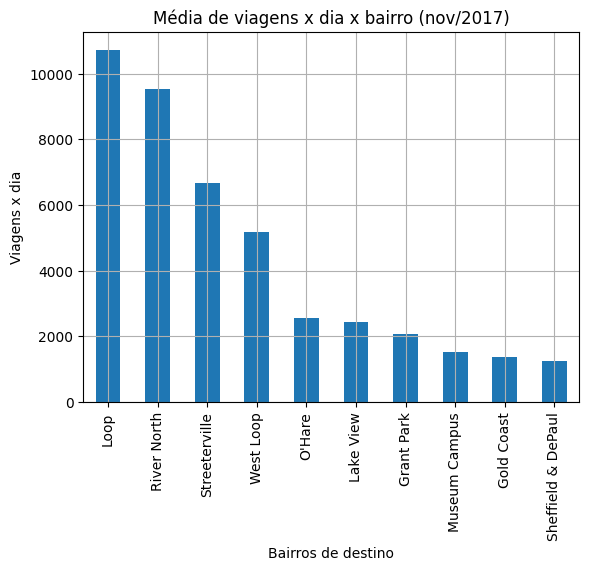

In [10]:
top10_destiny_neighb.plot(kind='bar', x='dropoff_location_name', y='average_trips', title='Média de viagens x dia x bairro (nov/2017)', legend=False, grid=True, xlabel='Bairros de destino', ylabel='Viagens x dia')

### Principais achados da exploração
_Obs.: parto do princípio de que, neste momento, não tenho acesso a todos os dados anteriormente obtidos com SQL_

**Sobre o gráfico "Empresas de táxi e número de corridas"**
* A empresa Flash Cab tem quase o dobro do número de corridas que a segunda colocada tem para o mesmo período (15 a 16 de novembro de 2017). Isso sinaliza para uma presença mais sólida no mercado da empresa Flash Cab do que todas as demais.
* A diferença de corridas entre as demais 63 empresas com dados no conjunto decresce de forma mais estável ao longo do ranking, diferentemente da já relatada diferença da primeira, Flash Cab, para a segunda. Essa percepção pode reforçar a ideia de concentração de mercado.

**Sobre o gráfico "Top 10 bairros por número de corridas em que esse bairro é destino"**

* Há quatro bairros que se destacam dos demais do top10. São: Loop, River North, Streeterville  e West Loop.
* Ainda é possível constatar que Loop e River North se destacam de Streeterville  e West Loop, como se houvesse dois grupos dentro do top 4.
* A concentração de destinos em Loop, River North, Streeterville e West Loop levanta hipóteses sobre centralidade econômica, turismo e lazer. Os dados disponíveis, porém, não permitem determinar a causa dessa concentração.


## Teste de hipótese: clima e duração das corridas

É testada a hipótese de que a duração média das viagens entre Loop e o Aeroporto Internacional O'Hare difere entre sábados classificados como `Good` e `Bad` em relação às condições climáticas.


In [11]:
loop_airport_trips = pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/learning-materials/data-analyst-eng/moved_project_sql_result_07.csv')
loop_airport_trips.sample(20, random_state=29)

,start_ts,weather_conditions,duration_seconds
626,2017-11-04 08:00:00,Good,1260.0
547,2017-11-04 08:00:00,Good,1757.0
908,2017-11-11 11:00:00,Good,1680.0
754,2017-11-18 15:00:00,Good,3240.0
637,2017-11-11 14:00:00,Good,2400.0
87,2017-11-18 05:00:00,Good,2075.0
959,2017-11-11 07:00:00,Good,1260.0
347,2017-11-11 17:00:00,Good,2460.0
557,2017-11-11 12:00:00,Good,2029.0
380,2017-11-11 07:00:00,Good,1261.0


In [12]:
# criando amostras

good = loop_airport_trips[loop_airport_trips['weather_conditions'] == 'Good']['duration_seconds']
bad = loop_airport_trips[loop_airport_trips['weather_conditions'] == 'Bad']['duration_seconds']

In [14]:
#hipóteses

## H0: a duração média das corridas é igual em sábados, independendo de clima
## H1: a duração média das corridas difere entre as condições climáticas

alpha = 0.05

results = stats.ttest_ind(good, bad, equal_var=False)

display(results.pvalue)

if results.pvalue >= alpha:
    print('Não é possível rejeitar a hipótese nula')
else:
    print('Rejeitamos a hipótese nula')


6.738994326108734e-12

Rejeitamos a hipótese nula


### Conclusão

Em teste a seguinte hipótese: "A duração média dos passeios do Loop para o Aeroporto Internacional O'Hare muda nos sábados chuvosos".

* Para testá-la, defini como hipótese nula um cenário sem modificação a partir da inserção do elemento climático. Ou seja, que a duração média dos passeios do Loop para o Aeroporto Internacional O'Hare não mudaria nos sábados chuvosos.
* A partir da tabela anteriormente criada com SQL, criei com Python as amostras que indicavam tempo "Good" e separei os valores de duração em segundos associados; e tempo "Bad" com valores de duração em segundos associados.
* As amostras em teste já continham apenas sábados desde o SQL, então não foi necessário filtrar por esse aspecto.
* Defini alpha em 0.05, nível de significância convencional de 5%.
* Apliquei o ttest_ind, pois as amostras de tempo "bom" e "ruim" são independentes entre si (não são amostras, por exemplo, da mesma corrida antes e durante a chuva, mas sim de corridas diferentes).
* Utilizei equal_var=False porque não assumi que as duas populações tivessem variâncias iguais.
* Como o p-valor foi muito inferior a 0,05, rejeita-se a hipótese nula.
* Portanto, os dados fornecem evidência estatisticamente significativa de que a duração média das corridas difere entre sábados com condições climáticas Good e Bad.

## Conclusão geral

A análise mostrou concentração das corridas em algumas empresas e bairros de destino, além de evidência estatisticamente significativa de diferença na duração média das corridas entre condições climáticas Good e Bad aos sábados no trajeto Loop–O'Hare.

A diferença observada entre condições climáticas justifica investigar fatores operacionais associados, como disponibilidade de frota, congestionamento e política de preços. O teste identifica diferença entre os grupos, mas não estabelece sozinho a causa dessa diferença.
